In [1]:
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

In [2]:
cwd = Path.cwd().parent
data_dir = cwd / 'data'

cmg_data = pd.read_csv(data_dir / 'AllScenarios_CMG.csv')

## Visualize NaN

<Axes: >

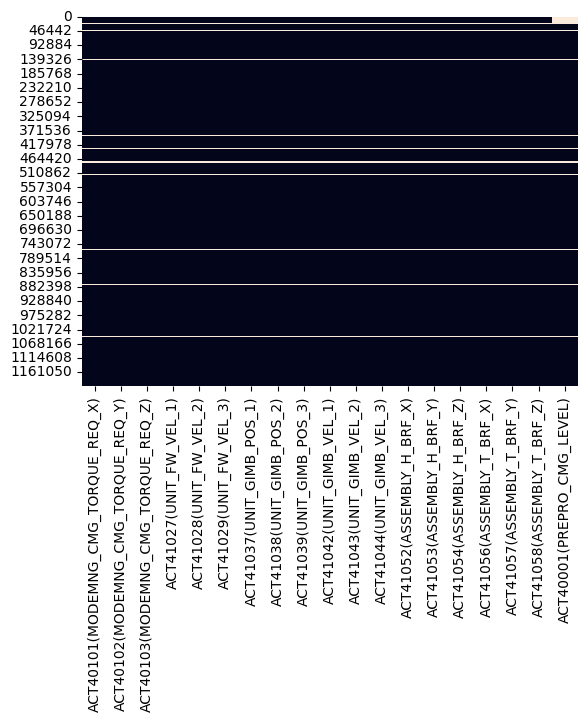

In [3]:
sns.heatmap(cmg_data.isnull(), cbar=False)

# Data Preprocessing


## Cleaning

In [4]:
cmg_cleaned = cmg_data.dropna(ignore_index = True)

## Splitting

### Seed Trial

In [ ]:
import random

random_seed = 42

random.seed(random_seed)

print(random.random())

random.sample(
	range(10),
	5
)

In [ ]:
import random

random_seed = 10

random.seed(random_seed)

print(random.random())

random.sample(
	range(10),
	5
)

In [ ]:
random.sample(
	range(10),
	5, 
	
)

### Split method

In [5]:
import random
from itertools import chain

def split_indices(df, window_size, overlap, windows_per_chunk=100, 
				train_split=0.8, val_split=0.1, test_split=0.1,
				start_seed = 42
				) -> tuple[list[int], list[int], list[int]]:
	"""
	Split dataframe indices using chunk-based strategy.

	Args:
		df: Cleaned pandas DataFrame
		window_size: Size of sliding window
		overlap: Overlap fraction (0.0-0.99)
		windows_per_chunk: Number of windows per chunk
		train_split, val_split, test_split: Split ratios
		random_seed: Random seed for reproducibility

	Returns:
		tuple: (train_indices, val_indices, test_indices)
	"""
	random_seed = start_seed

	random.seed(random_seed)

	stride = max(1, int(window_size * (1 - overlap)))
	total_points = len(df)
	total_windows = (total_points - window_size) // stride + 1
	tot_chunks = total_windows // windows_per_chunk

	data_indices = df.index.tolist()
	test_points = test_split * total_points
	val_points = val_split * total_points

	# Test set
	test_indices = data_indices[-int(test_points):]
	train_val_indices = data_indices[:-int(test_points)]

	train_val_block_chunks = [
		train_val_indices[i:i + tot_chunks] 
		for i in range(0, len(train_val_indices), tot_chunks)
	]

	# Adjusted original validation set percentage
	sample_percentage = round(val_points/len(train_val_indices), 2)

	# List of all block chunks indices
	block_chunks_indices = list(range(0, len(train_val_block_chunks)))

	# Validation set
	val_block_chunks_indices = sorted(random.sample(
			block_chunks_indices,
			k = int(len(train_val_block_chunks) * sample_percentage)
		)
	)
	val_dataset_blocks_indices = [
		train_val_block_chunks[i] for i in val_block_chunks_indices
	]

	val_indices = list(chain.from_iterable(val_dataset_blocks_indices))

	# Train set
	train_block_chunks_indices = [
		x for x in block_chunks_indices 
		if x not in set(val_block_chunks_indices)
	]

	train_dataset_blocks_indices = [
		train_val_block_chunks[i] for i in train_block_chunks_indices
	]

	train_indices = list(
		chain.from_iterable(train_dataset_blocks_indices)
	)
	
	return train_indices, val_indices, test_indices

In [6]:
train_indices, val_indices, test_indices = split_indices(
	df = cmg_cleaned, 
	window_size = 16,
	overlap = 0.8,
	windows_per_chunk= 100,
	train_split= 0.7,
	val_split= 0.20,
	test_split= 0.10
)

In [7]:
print(
	"\n train_indices", len(train_indices),
	"\n val_indices", len(val_indices),
	"\n test_indices", len(test_indices)
)


 train_indices 809810 
 val_indices 226383 
 test_indices 115132


In [8]:
train_df = cmg_cleaned.loc[train_indices,:].copy()
val_df = cmg_cleaned.loc[val_indices,:].copy()
test_df = cmg_cleaned.loc[test_indices,:].copy()

### Visualize splits

In [ ]:
data_to_plot = train_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
	data=data_to_plot,
	x=data_to_plot.index,
	y=data_to_plot.columns[feature]
)

plt.show()

In [ ]:
data_to_plot = train_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
	data=data_to_plot,
	x=data_to_plot.index,
	y=data_to_plot.columns[feature]
)

plt.show()

In [ ]:
data_to_plot = test_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
	data=data_to_plot,
	x=data_to_plot.index,
	y=data_to_plot.columns[feature]
)

plt.show()

In [ ]:
data_to_plot = test_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
	data=data_to_plot,
	x=data_to_plot.index,
	y=data_to_plot.columns[feature]
)

plt.show()

In [ ]:
data_to_plot = val_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
	data=data_to_plot,
	x=data_to_plot.index,
	y=data_to_plot.columns[feature]
)

plt.show()

In [ ]:
data_to_plot = val_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
	data=data_to_plot,
	x=data_to_plot.index,
	y=data_to_plot.columns[feature]
)

plt.show()

## Standardization

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_std = scaler.fit_transform(train_df).astype(np.float32)
val_std = scaler.transform(val_df).astype(np.float32)
test_std = scaler.transform(test_df).astype(np.float32)

print(
	"\n train_std.shape", train_std.shape,
	"\n val_std.shape", val_std.shape,
	"\n test_std.shape", test_std.shape
)


 train_std.shape (809810, 19) 
 val_std.shape (226383, 19) 
 test_std.shape (115132, 19)


## Sequencing

In [ ]:
window_size = 16
overlap = 0.8

lenght = train_std.shape[0]
# lenght = 4

stride = max(1, int(window_size * (1 - overlap)))
num_windows = (
	(lenght - window_size) // stride
	) + 1


print(
	"\n num_windows", num_windows,
	"\n stride", stride
)

In [10]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

class SignalWindowDataset(Dataset):
	"""Memory-efficient dataset that creates windows on-the-fly"""

	def __init__(self, std_data, window_size=16, overlap=0.0, n_signals=19):
		"""
		Args:
			std_data: Standardized pandas DataFrame
			window_size: Number of time points per window (default: 16)
			overlap: Overlap fraction between windows, 0.0 to 0.99 (default: 0.0)
			n_signals: Number of signal channels (default: 19)
		"""

		self.data = std_data
		# TODO: handle case where window_size is greater than data.shape[0]
		self.window_size = window_size
		self.n_signals = n_signals

		# Calculate stride based on overlap
		# TODO: handle case where overlap is 0
		# TODO: handle case where overlap is greater than 1
		# TODO: handle case where overlap is negative
		self.stride = max(1, int(window_size * (1 - overlap)))

		# Calculate number of windows
		self.n_windows = (
			(self.data.shape[0] - window_size) // self.stride
			) + 1

	def __len__(self):
		return self.n_windows

	def __getitem__(self, idx):
		start = idx * self.stride
		end = start + self.window_size
		window = self.data[start:end, :].T
		window = window[np.newaxis, :, :]
		return torch.from_numpy(window)

In [11]:
current_batch_size = 32

train_seq = SignalWindowDataset(
	std_data = train_std,
	window_size = 16,
	overlap = 0.8,
	n_signals = train_std.shape[1]
)

train_loader = DataLoader(
	train_seq,
	batch_size = current_batch_size,
	shuffle = False,
	num_workers = 4
)

# train_batch = next(iter(train_loader))

# print(
# 	f"\n Shape -- {train_batch.shape}",
# 	f"\n Total Training Windows -- {len(train_seq)}"
# )

In [12]:
val_seq = SignalWindowDataset(
	std_data = val_std,
	window_size = 16,
	overlap = 0.8,
	n_signals = val_std.shape[1]
)

val_loader = DataLoader(
	val_seq,
	batch_size = current_batch_size,
	shuffle = False,
	num_workers = 4
)

# val_batch = next(iter(val_loader))

# print(
# 	f"\n Shape -- {val_batch.shape}",
# 	f"\n Total Validation Windows -- {len(val_seq)}"
# )

## Perturbations - Wombats

In [ ]:
pass

# Model

In [13]:
import torch.nn as nn

from models.conv_ae2D import CONV_AE2D

In [14]:
models_dir = cwd / 'models'
cmg_model_dir = models_dir / 'cmg'
best_cmg_model_path = cmg_model_dir / 'best_parameters_opt/model.pt'

### Checkpoint

```

- 'epoch'
- 'model_state_dict'
- 'optimizer_state_dict'
- 'loss'
- 'loss_value'
- 'cfg'
- 'scaler_params_pre_training'
- 'scaler_params_fine_tuning'
- 'parameters_number'
- 'param_conf'
- 'metric_score'
- 'data_path'
- 'indices_path'
- 'scaler_path'
- 'metric_dataset_path'
- 'indices'
 ```

In [15]:
best_model_dict = torch.load(best_cmg_model_path, weights_only=False)

cfg = best_model_dict['cfg']
model_state_dict = best_model_dict['model_state_dict']

In [16]:
best_model = CONV_AE2D(cfg)
best_model.load_state_dict(model_state_dict)
best_model.eval()

🔧 Encoder: Symmetric architecture (no bottleneck conv)
Initializing conv2d weights with Kaiming He normal
Initializing conv2d weights with Kaiming He normal


CONV_AE2D(
  (act): ReLU(inplace=True)
  (encoder): Encoder(
    (act): ReLU(inplace=True)
    (encoder): Sequential(
      (enc_lay_1): Sequential(
        (0): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0), dilation=1, ceil_mode=False)
      )
      (enc_lay_2): Sequential(
        (0): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0), dilation=1, ceil_mode=False)
      )
    )
    (bottleneck): Sequential(
      (flatten): Flatten(start_dim=1, end_dim=-1)
      (to_latent): Linear(in_features=1024, out_features=76, bias=True)
    )
  )
  (decoder): Decoder(
 

In [17]:
model = CONV_AE2D(cfg)

🔧 Encoder: Symmetric architecture (no bottleneck conv)
Initializing conv2d weights with Kaiming He normal
Initializing conv2d weights with Kaiming He normal


## Loss function

In [18]:
criterion = nn.MSELoss()

## Optimizer

In [19]:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

## LR Scheduler

In [20]:
cfg.opt.epochs
# 'lr': 0.001, 'batch_size': 300, 'epochs': 300, 'lr_patience': 10, 'es_patience': 10

300

In [21]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
	optimizer,
	mode=cfg.opt.opt_metric.val_roc_auc,
	factor=0.8,
	patience=cfg.opt.lr_patience,
	threshold=0.0001,
	threshold_mode='rel',
	cooldown=0,
	min_lr=9e-8
)

## Device Selection

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Training



## Classic

In [ ]:
from tqdm import tqdm

num_epochs = cfg.opt.epochs

# Basic training loop structure
for epoch in range(num_epochs):
	# Training phase
	model.train()
	train_loss = 0.0

	train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
	for batch_idx, data in enumerate(train_pbar):
		# data should be shape: (batch_size, channels, height, width)
		inputs = data.to(device)
		
		# Forward pass
		outputs = model(inputs)
		loss = criterion(outputs, inputs)
		
		# Backward pass
		optimizer.zero_grad()
		loss.backward()
		optimizer.step()
		
		train_loss += loss.item()

		# Update progress bar with current loss
		train_pbar.set_postfix({'loss': loss.item()})
	
	avg_train_loss = train_loss / len(train_loader)
	
	# Validation phase
	model.eval()
	val_loss = 0.0
	val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
	with torch.no_grad():
		for data in val_pbar:
			inputs = data.to(device)
			outputs = model(inputs)
			loss = criterion(outputs, inputs)
			val_loss += loss.item()
	
	avg_val_loss = val_loss / len(val_loader)
	
	# Learning rate scheduling
	if scheduler:
		scheduler.step(avg_val_loss)
	
	print(
		f'Epoch [{epoch+1}/{num_epochs}], '
		f'Train Loss: {avg_train_loss:.4f}, '
		f'Val Loss: {avg_val_loss:.4f}',
		'\n\n'
	)

## with tqdm

In [ ]:
from tqdm import tqdm

num_epochs = cfg.opt.epochs

# Basic training loop structure
for epoch in range(num_epochs):
	# Training phase
	model.train()
	train_loss = 0.0

	train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
	for batch_idx, data in enumerate(train_pbar):
		# data should be shape: (batch_size, channels, height, width)
		inputs = data.to(device)
		
		# Forward pass
		outputs = model(inputs)
		loss = criterion(outputs, inputs)
		
		# Backward pass
		optimizer.zero_grad()
		loss.backward()
		optimizer.step()
		
		train_loss += loss.item()

		# Update progress bar with current loss
		train_pbar.set_postfix({'loss': loss.item()})
	
	avg_train_loss = train_loss / len(train_loader)
	
	# Validation phase
	model.eval()
	val_loss = 0.0
	val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
	with torch.no_grad():
		for data in val_pbar:
			inputs = data.to(device)
			outputs = model(inputs)
			loss = criterion(outputs, inputs)
			val_loss += loss.item()
	
	avg_val_loss = val_loss / len(val_loader)
	
	# Learning rate scheduling
	if scheduler:
		scheduler.step(avg_val_loss)
	
	print(
		f'Epoch [{epoch+1}/{num_epochs}], '
		f'Train Loss: {avg_train_loss:.4f}, '
		f'Val Loss: {avg_val_loss:.4f}',
		'\n\n'
	)

## with Tensorboard

In [ ]:
import datetime

from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

num_epochs = cfg.opt.epochs
num_train_batches = len(train_loader)
num_val_batches = len(val_loader)

# Create a unique run name with timestamp
run_name = f"conv_ae_run_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(f'runs/{run_name}')

# Optionally log hyperparameters
writer.add_text('config', str(cfg))

global_step = 0  # Track total batches across all epochs


for epoch in range(num_epochs):
	# Training phase
	model.train()
	train_loss = 0.0
	
	train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')

	for batch_idx, data in enumerate(train_pbar):
		inputs = data.to(device)
		outputs = model(inputs)
		loss = criterion(outputs, inputs)
		
		optimizer.zero_grad()
		loss.backward()
		
		total_norm = 0.0
		for p in model.parameters():
			if p.grad is not None:
				total_norm += p.grad.data.norm(2).item() ** 2
		total_norm = total_norm ** 0.5
		writer.add_scalar('Gradients/global_norm', total_norm, global_step)
		
		optimizer.step()
		
		train_loss += loss.item()
		train_pbar.set_postfix({'loss': loss.item()})
		
		# Log batch loss to TensorBoard
		writer.add_scalar('Loss/train_batch', loss.item(), global_step)
		global_step += 1
	
	avg_train_loss = train_loss / num_train_batches
	
	# Validation phase
	model.eval()
	val_loss = 0.0
	val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')

	with torch.no_grad():
		for data in val_pbar:
			inputs = data.to(device)
			outputs = model(inputs)
			loss = criterion(outputs, inputs)
			val_loss += loss.item()
			val_pbar.set_postfix({'loss': loss.item()})
	
	avg_val_loss = val_loss / num_val_batches
	
	# Log epoch metrics to TensorBoard
	writer.add_scalar('Loss/train_epoch', avg_train_loss, epoch)
	writer.add_scalar('Loss/val_epoch', avg_val_loss, epoch)

	# Overfitting gap — useful to spot divergence early
	writer.add_scalar('Loss/train_val_gap', avg_train_loss - avg_val_loss, epoch)

	# Log learning rate
	current_lr = optimizer.param_groups[0]['lr']
	writer.add_scalar('Learning_Rate', current_lr, epoch)
	
	if epoch % 5 == 0:
		# Weight histograms (Spot dead neurons / saturation)
		for name, param in model.named_parameters():
			writer.add_histogram(f'Weights/{name}', param.data, epoch)
			if param.grad is not None:
				writer.add_histogram(f'Gradients/{name}', param.grad, epoch)

		# Log reconstruction examples (every N epochs)
		with torch.no_grad():
			sample_input = inputs[:4]  # First 4 samples
			sample_output = outputs[:4]
			
			# error is distributed across a batch
			per_sample_loss = torch.nn.functional.mse_loss(
				sample_output, sample_input, reduction='none'
				)
			per_sample_loss = per_sample_loss.mean(
				dim=list(range(1, per_sample_loss.ndim))
				)
			writer.add_histogram(
				'Loss/reconstruction_distribution', per_sample_loss, epoch
				)

			fig, ax = plt.subplots()
			ax.plot(inputs[0].cpu().numpy().flatten(), label='Input')
			ax.plot(outputs[0].cpu().numpy().flatten(), label='Reconstruction')
			ax.legend()
			writer.add_figure('Reconstruction/sample', fig, epoch)
			plt.close(fig)
	
	# Learning rate scheduling
	if scheduler:
		scheduler.step(avg_val_loss)
	
	print(
		f'Epoch [{epoch+1}/{num_epochs}], '
		f'Train Loss: {avg_train_loss:.4f}, '
		f'Val Loss: {avg_val_loss:.4f}',
		'\n\n'
	)

# Close the writer when training is complete
writer.close()

Epoch 1/300 [Val]: 100%|██████████| 2358/2358 [00:08<00:00, 266.13it/s, loss=0.157]


Epoch [1/300], Train Loss: 0.6060, Val Loss: 0.9907 




Epoch 2/300 [Val]: 100%|██████████| 2358/2358 [00:08<00:00, 263.22it/s, loss=0.154]


Epoch [2/300], Train Loss: 0.5786, Val Loss: 1.1101 




Epoch 3/300 [Val]: 100%|██████████| 2358/2358 [00:08<00:00, 264.81it/s, loss=0.15] 


...

Epoch 44/300 [Val]: 100%|██████████| 2358/2358 [00:07<00:00, 332.87it/s, loss=0.0471]


Epoch [44/300], Train Loss: 0.2541, Val Loss: 0.5774 




Epoch 45/300 [Val]: 100%|██████████| 2358/2358 [00:08<00:00, 288.96it/s, loss=0.0469]


Epoch [45/300], Train Loss: 0.2084, Val Loss: 0.6098 




Epoch 46/300 [Train]:  18%|█▊        | 1560/8436 [00:18<01:48, 63.33it/s, loss=0.0543] 